In [12]:
'''
Simple MPL
Autor: Maria Hadam
28.06.2026
Edited: Ziemowit Olinkiewicz
20.07.2026
'''

import json
import torch
import sys
sys.path.append("./source")

from pathlib import Path
import model as mlp
import numpy as np
import lindblad_solver as solver
import dataset as ds
import training as t
import plotting as plt

import matplotlib.pyplot as mpl
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

root_save = "results/20_40_80ps_e4lr_mlp_dataloss_evenspacedtimes"

In [14]:
#odczyt

save_dir = Path(root_save)

with open(save_dir / "config.json", "r", encoding="utf-8") as f:
    configdata = json.load(f)

root_train = configdata["trainroot"]
root_test = configdata["testroot"]
device = configdata["device"]

pinn = torch.load(
   save_dir / "model.pt",
    map_location=device,
    weights_only=False
)

featuretimes = np.load(save_dir / "featuretimes.npy")

In [16]:
#kawalek kodu do wyciagania wynikow z ML i porownywania z prawdziwymi labelkami
pinn.eval()

labels_true, labels_pred, labels_train_true, labels_train_pred = plt.LoadLabels(root_train, root_test, featuretimes, device, pinn)

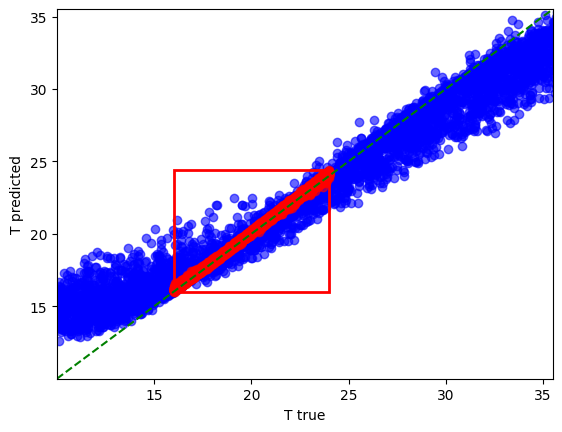

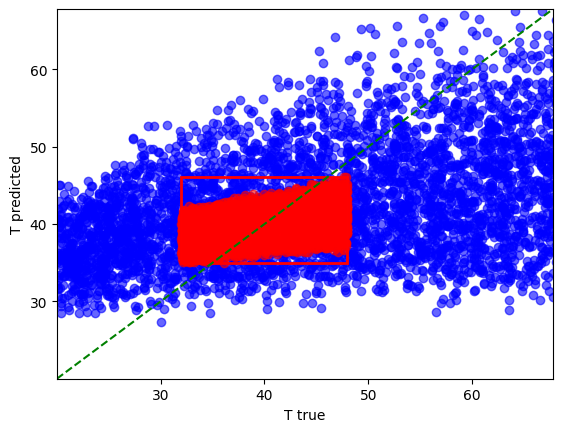

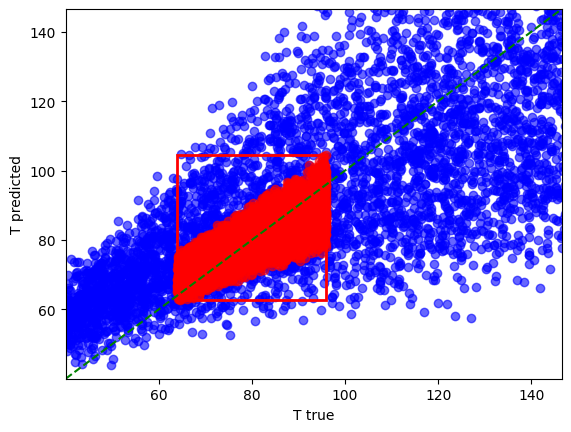

[29.438047 27.844664 44.014126 27.446154 91.58257 ]
[28.705242 26.619127 39.1084   40.355865 79.60323 ]


In [17]:
#col = 4 #0,1 - relax; 2,3 - dephas; 4 - cor dephas

plt.PlotCorelations(0, root_save, labels_true, labels_pred, labels_train_true, labels_train_pred)

plt.PlotCorelations(2, root_save, labels_true, labels_pred, labels_train_true, labels_train_pred)

plt.PlotCorelations(4, root_save, labels_true, labels_pred, labels_train_true, labels_train_pred)

num = 52
print(labels_true[num, :])
print(labels_pred[num, :])

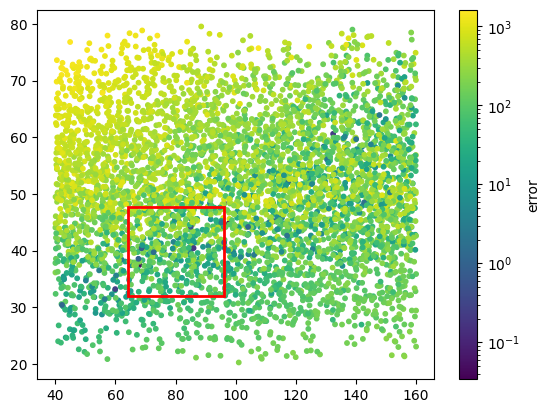

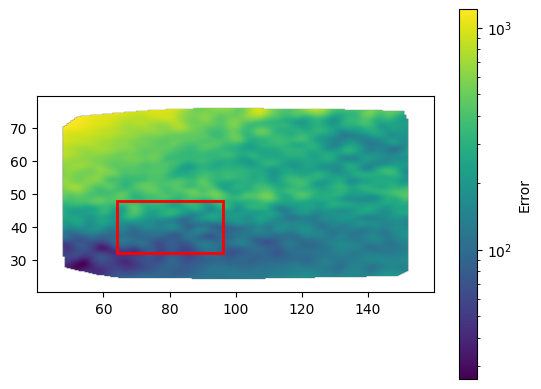

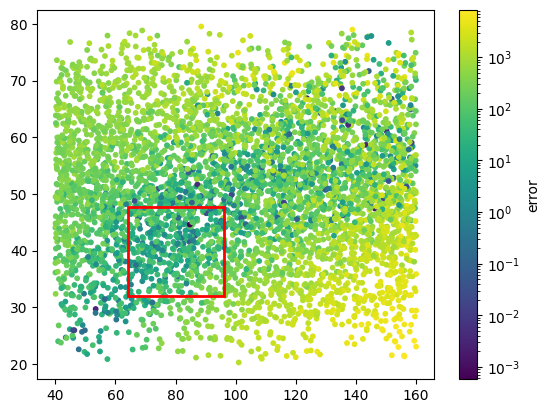

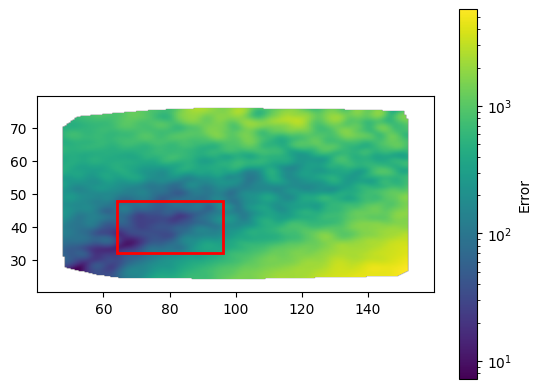

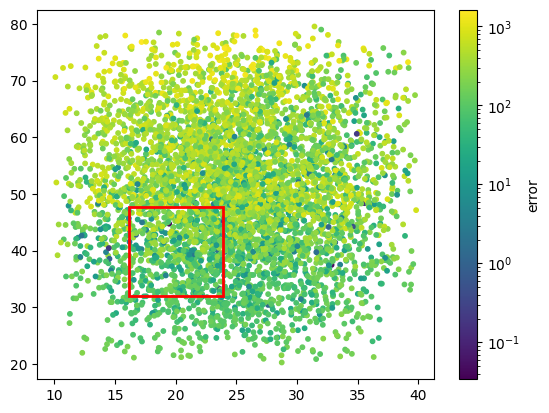

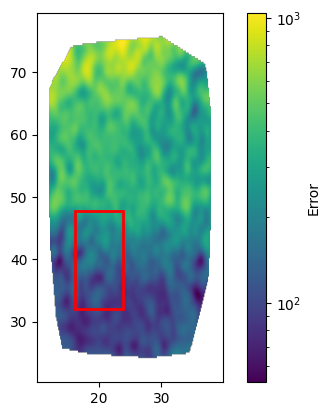

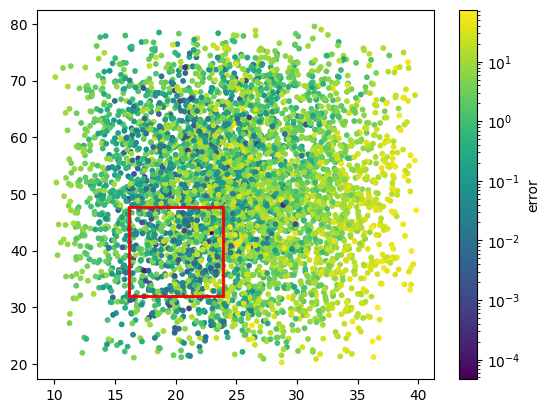

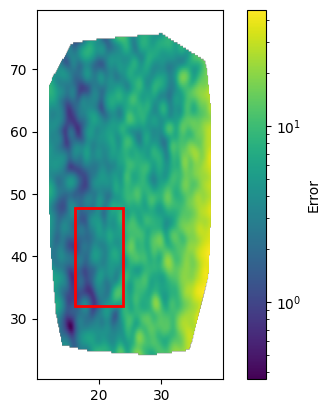

In [18]:
plt.PlotErrorColor([4], [2,3], [2,3], root_save, labels_true, labels_pred, labels_train_true, labels_train_pred)

plt.PlotErrorColor([4], [2,3], [4], root_save, labels_true, labels_pred, labels_train_true, labels_train_pred)

plt.PlotErrorColor([0,1], [2,3], [2,3], root_save, labels_true, labels_pred, labels_train_true, labels_train_pred)

plt.PlotErrorColor([0,1], [2,3], [0,1], root_save, labels_true, labels_pred, labels_train_true, labels_train_pred)


#xaxis = np.diff(labels_true[:, x_cols], axis=1).mean(axis=1)

In [ ]:
diff_cols = [0,1,2,3,4]
taudiff = np.sqrt(((labels_true[:,diff_cols]-20)**2).sum(axis=1))

mpl.scatter(taudiff, error)
mpl.yscale('log')      # oś X logarytmiczna
mpl.xlabel("taudiff")
mpl.ylabel("error")
mpl.show()